# Análisis Exploratorio del Dataset Titanic

## Introducción
El hundimiento del Titanic es uno de los naufragios más infames de la historia. El 15 de abril de 1912, durante su viaje inaugural, el Titanic se hundió después de chocar con un iceberg, matando a 1502 de 2224 pasajeros y tripulación.

En este análisis exploraremos los datos de los pasajeros para descubrir patrones y factores que influyeron en la supervivencia.

## 1. Importación de Librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Carga de Datos

In [2]:
# Cargar el dataset desde seaborn (viene incluido)
df = sns.load_dataset('titanic')

# Hacer una copia para trabajar
df_original = df.copy()

print(f"Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

Dataset cargado: 891 filas y 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Exploración Inicial de Datos

### 3.1 Información General

In [3]:
# Información del dataset
print("=" * 50)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
df.info()

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
# Descripción de las columnas
print("\n" + "=" * 50)
print("DESCRIPCIÓN DE LAS VARIABLES")
print("=" * 50)
print("""
- survived: Supervivencia (0 = No, 1 = Sí)
- pclass: Clase del billete (1 = 1ra, 2 = 2da, 3 = 3ra)
- sex: Género
- age: Edad en años
- sibsp: Número de hermanos/cónyuges a bordo
- parch: Número de padres/hijos a bordo
- fare: Tarifa del pasajero
- embarked: Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton)
- class: Clase del pasajero
- who: Hombre, mujer o niño
- adult_male: Si es hombre adulto
- deck: Cubierta del camarote
- embark_town: Ciudad de embarque
- alive: Supervivencia (yes/no)
- alone: Si viajaba solo
""")


DESCRIPCIÓN DE LAS VARIABLES

- survived: Supervivencia (0 = No, 1 = Sí)
- pclass: Clase del billete (1 = 1ra, 2 = 2da, 3 = 3ra)
- sex: Género
- age: Edad en años
- sibsp: Número de hermanos/cónyuges a bordo
- parch: Número de padres/hijos a bordo
- fare: Tarifa del pasajero
- embarked: Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton)
- class: Clase del pasajero
- who: Hombre, mujer o niño
- adult_male: Si es hombre adulto
- deck: Cubierta del camarote
- embark_town: Ciudad de embarque
- alive: Supervivencia (yes/no)
- alone: Si viajaba solo



### 3.2 Estadísticas Descriptivas

In [5]:
# Estadísticas de variables numéricas
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Estadísticas de variables categóricas
df.describe(include=['object', 'category'])

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


### 3.3 Valores Nulos

In [7]:
# Análisis de valores nulos
print("=" * 50)
print("VALORES NULOS EN EL DATASET")
print("=" * 50)

missing_data = pd.DataFrame({
    'Total_Nulos': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Total_Nulos'] > 0].sort_values('Total_Nulos', ascending=False)
print(missing_data)

VALORES NULOS EN EL DATASET
             Total_Nulos  Porcentaje
deck                 688       77.22
age                  177       19.87
embarked               2        0.22
embark_town            2        0.22


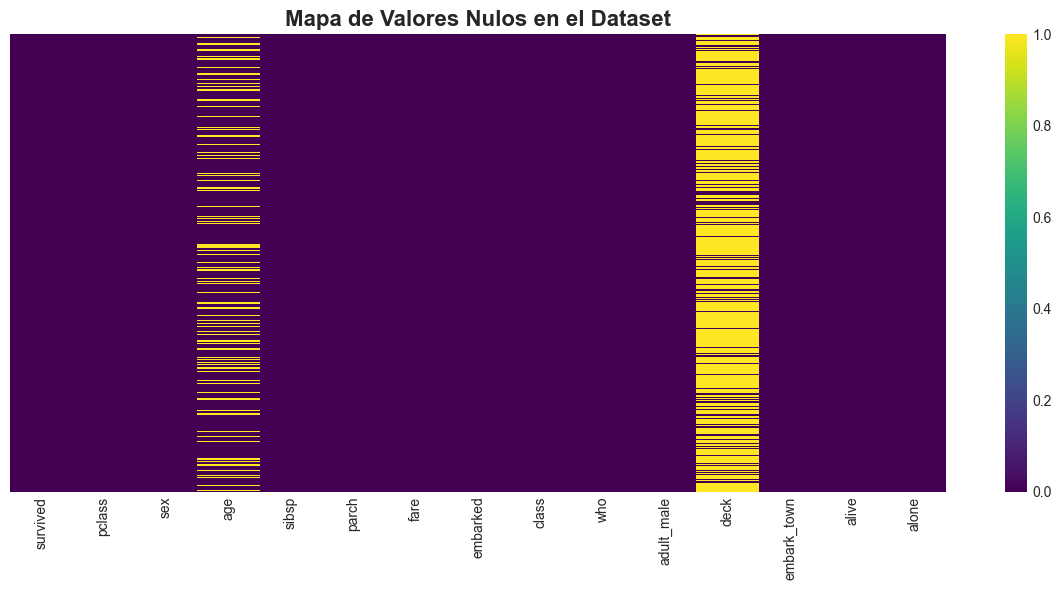

In [8]:
# Visualización de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos en el Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Limpieza de Datos

In [9]:
# Imputar la edad con la mediana
df['age'].fillna(df['age'].median(), inplace=True)

# Imputar el puerto de embarque con la moda
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)

# Para deck, lo dejaremos como está ya que tiene muchos nulos (puede ser información relevante)

print("Datos limpiados. Valores nulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Datos limpiados. Valores nulos restantes:
deck    688
dtype: int64


## 5. Análisis Univariado

### 5.1 Variable Objetivo: Supervivencia

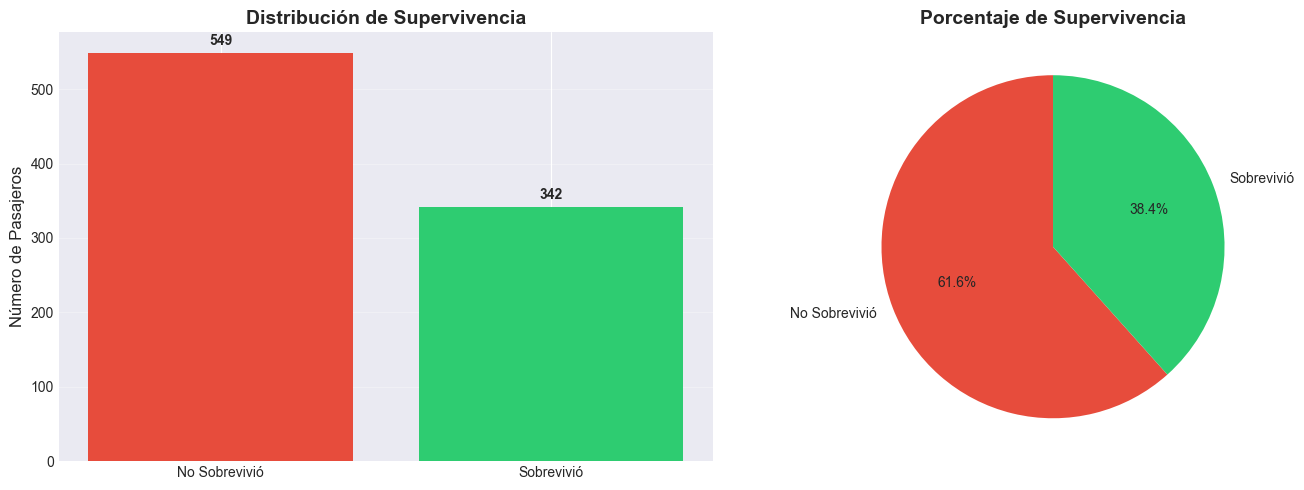


Tasa de supervivencia: 38.38%
Pasajeros que sobrevivieron: 342
Pasajeros que no sobrevivieron: 549


In [10]:
# Análisis de supervivencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
survival_counts = df['survived'].value_counts()
axes[0].bar(['No Sobrevivió', 'Sobrevivió'], survival_counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_ylabel('Número de Pasajeros', fontsize=12)
axes[0].set_title('Distribución de Supervivencia', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores encima de las barras
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(survival_counts.values, labels=['No Sobrevivió', 'Sobrevivió'], 
           autopct='%1.1f%%', startangle=90, colors=['#e74c3c', '#2ecc71'])
axes[1].set_title('Porcentaje de Supervivencia', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTasa de supervivencia: {df['survived'].mean()*100:.2f}%")
print(f"Pasajeros que sobrevivieron: {survival_counts[1]}")
print(f"Pasajeros que no sobrevivieron: {survival_counts[0]}")

### 5.2 Distribución de Edad

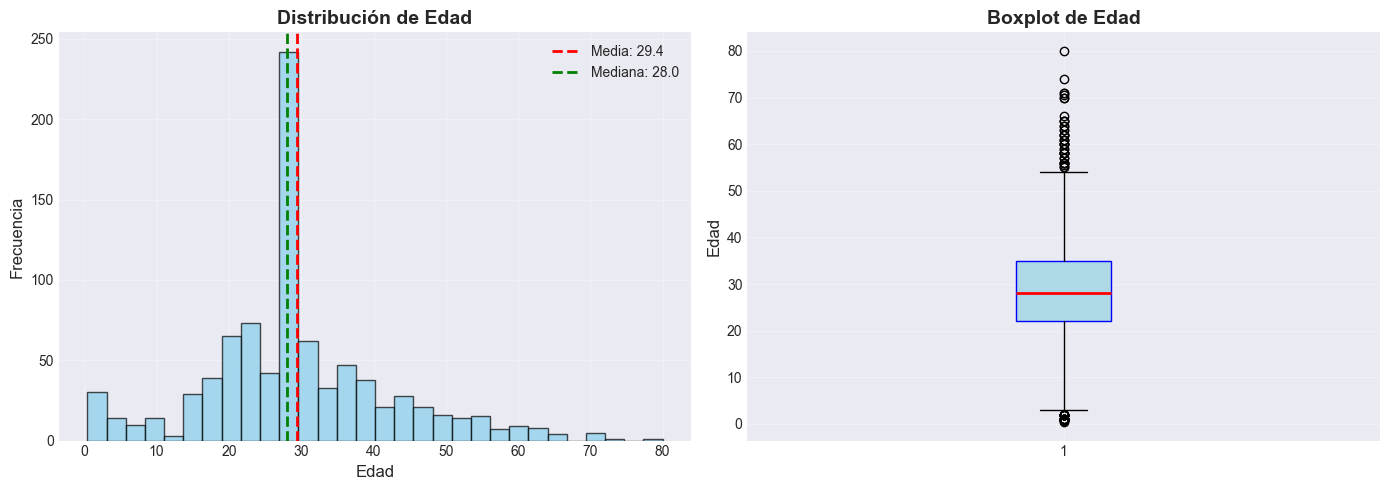


Estadísticas de Edad:
Media: 29.36 años
Mediana: 28.00 años
Edad mínima: 0.42 años
Edad máxima: 80.00 años


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["age"].median():.1f}')
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Edad', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df['age'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='blue'),
               medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Edad', fontsize=12)
axes[1].set_title('Boxplot de Edad', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de Edad:")
print(f"Media: {df['age'].mean():.2f} años")
print(f"Mediana: {df['age'].median():.2f} años")
print(f"Edad mínima: {df['age'].min():.2f} años")
print(f"Edad máxima: {df['age'].max():.2f} años")

### 5.3 Clase de Pasajero

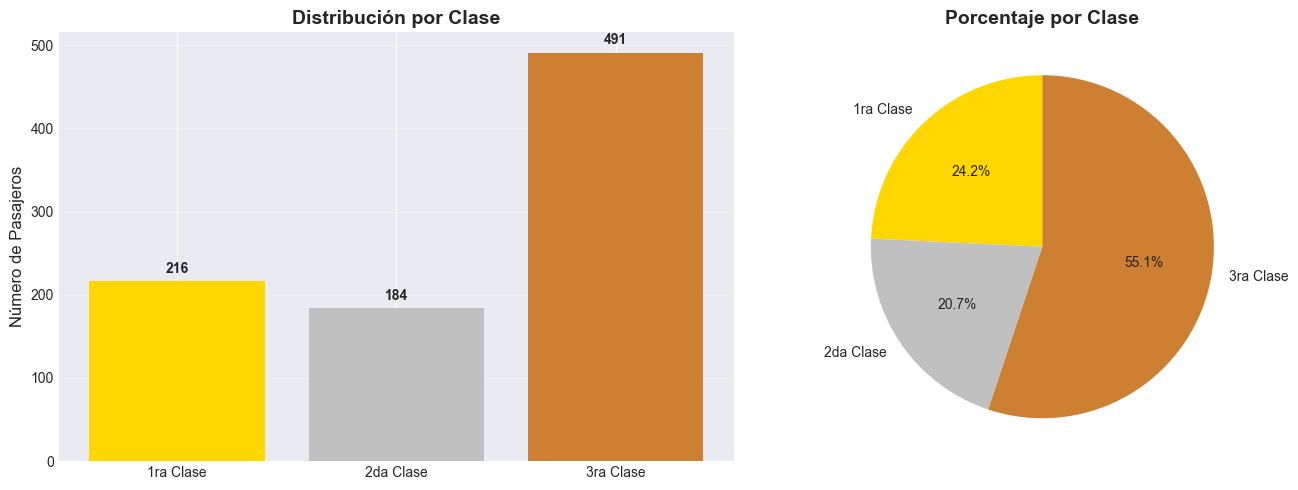

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por clase
class_counts = df['pclass'].value_counts().sort_index()
axes[0].bar(['1ra Clase', '2da Clase', '3ra Clase'], class_counts.values, color=['gold', 'silver', '#cd7f32'])
axes[0].set_ylabel('Número de Pasajeros', fontsize=12)
axes[0].set_title('Distribución por Clase', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(class_counts.values, labels=['1ra Clase', '2da Clase', '3ra Clase'], 
           autopct='%1.1f%%', startangle=90, colors=['gold', 'silver', '#cd7f32'])
axes[1].set_title('Porcentaje por Clase', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.4 Distribución por Género

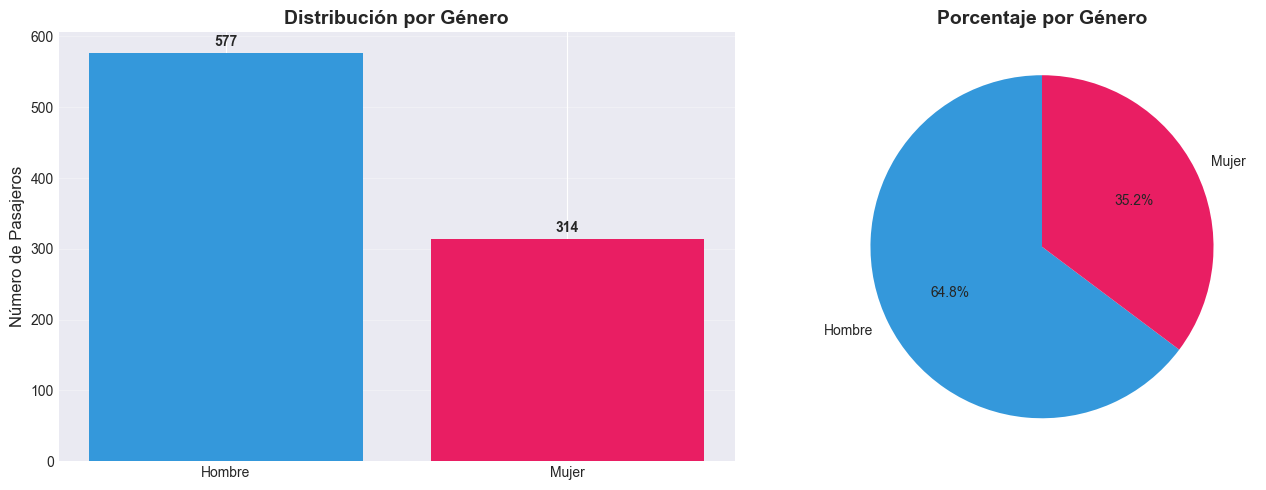

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por género
gender_counts = df['sex'].value_counts()
axes[0].bar(['Hombre', 'Mujer'], gender_counts.values, color=['#3498db', '#e91e63'])
axes[0].set_ylabel('Número de Pasajeros', fontsize=12)
axes[0].set_title('Distribución por Género', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(gender_counts.values, labels=['Hombre', 'Mujer'], 
           autopct='%1.1f%%', startangle=90, colors=['#3498db', '#e91e63'])
axes[1].set_title('Porcentaje por Género', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.5 Puerto de Embarque

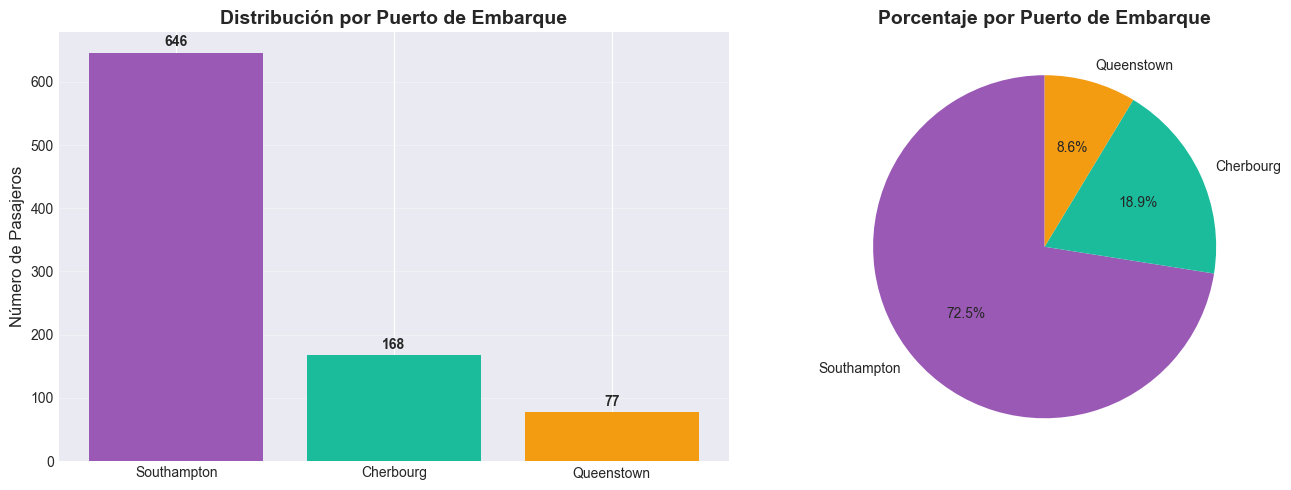

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por puerto
embark_counts = df['embarked'].value_counts()
axes[0].bar(['Southampton', 'Cherbourg', 'Queenstown'], embark_counts.values, color=['#9b59b6', '#1abc9c', '#f39c12'])
axes[0].set_ylabel('Número de Pasajeros', fontsize=12)
axes[0].set_title('Distribución por Puerto de Embarque', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(embark_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(embark_counts.values, labels=['Southampton', 'Cherbourg', 'Queenstown'], 
           autopct='%1.1f%%', startangle=90, colors=['#9b59b6', '#1abc9c', '#f39c12'])
axes[1].set_title('Porcentaje por Puerto de Embarque', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.6 Distribución de Tarifas

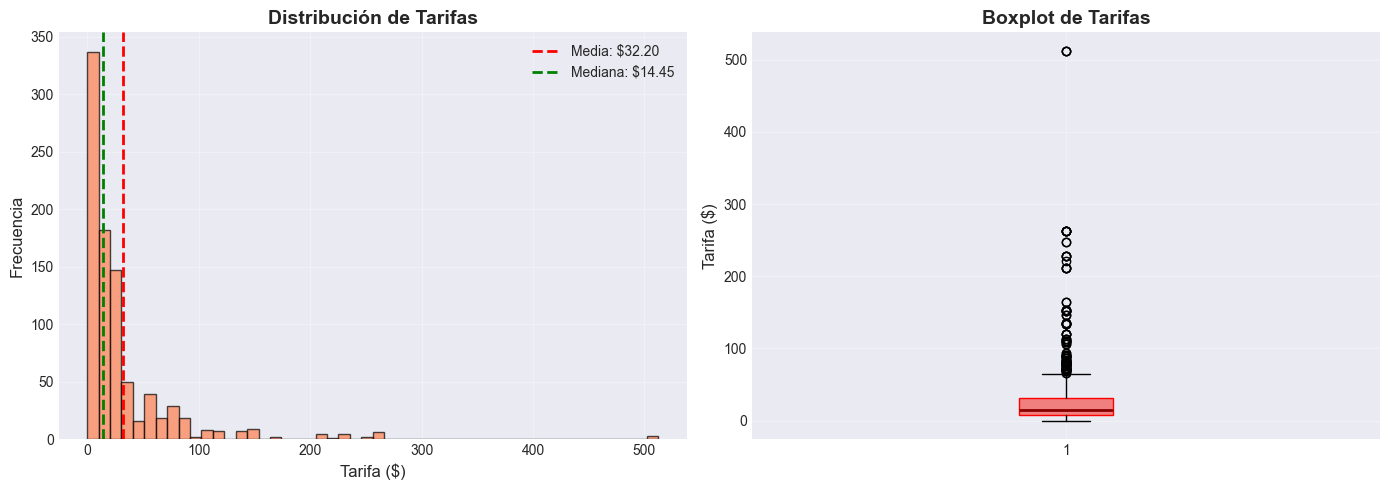


Estadísticas de Tarifa:
Media: $32.20
Mediana: $14.45
Tarifa mínima: $0.00
Tarifa máxima: $512.33


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['fare'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].axvline(df['fare'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["fare"].mean():.2f}')
axes[0].axvline(df['fare'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["fare"].median():.2f}')
axes[0].set_xlabel('Tarifa ($)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Tarifas', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df['fare'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightcoral', color='red'),
               medianprops=dict(color='darkred', linewidth=2))
axes[1].set_ylabel('Tarifa ($)', fontsize=12)
axes[1].set_title('Boxplot de Tarifas', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de Tarifa:")
print(f"Media: ${df['fare'].mean():.2f}")
print(f"Mediana: ${df['fare'].median():.2f}")
print(f"Tarifa mínima: ${df['fare'].min():.2f}")
print(f"Tarifa máxima: ${df['fare'].max():.2f}")

## 6. Análisis Bivariado

### 6.1 Supervivencia por Género

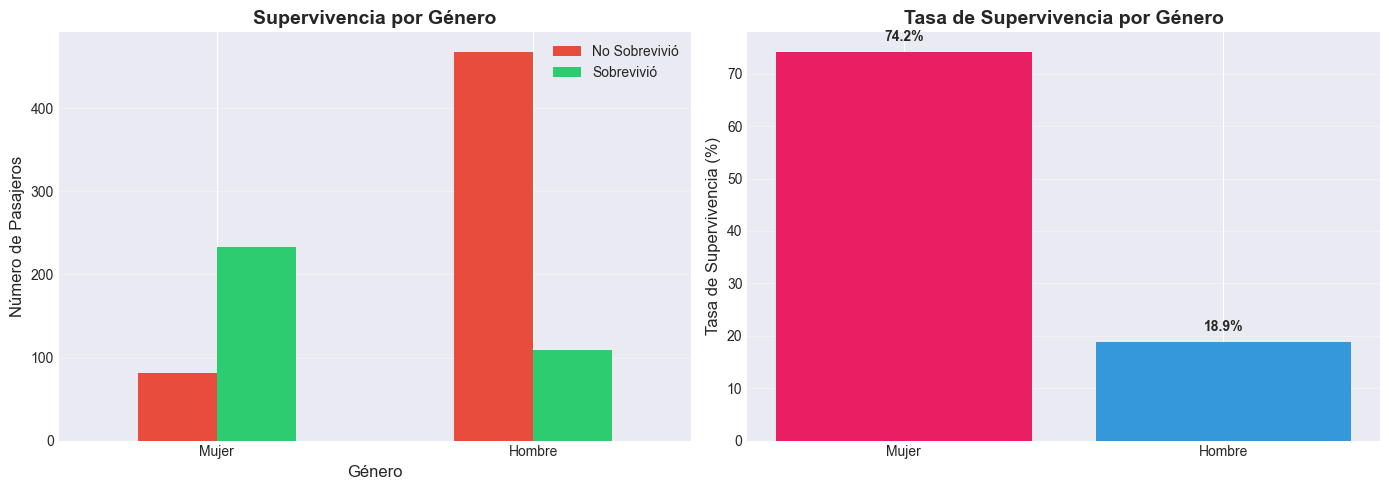


Tasa de supervivencia por género:
Mujeres: 74.20%
Hombres: 18.89%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras agrupadas
survival_by_gender = pd.crosstab(df['sex'], df['survived'])
survival_by_gender.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_xlabel('Género', fontsize=12)
axes[0].set_ylabel('Número de Pasajeros', fontsize=12)
axes[0].set_title('Supervivencia por Género', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Mujer', 'Hombre'], rotation=0)
axes[0].legend(['No Sobrevivió', 'Sobrevivió'])
axes[0].grid(axis='y', alpha=0.3)

# Tasa de supervivencia por género
survival_rate = df.groupby('sex')['survived'].mean()
axes[1].bar(['Mujer', 'Hombre'], survival_rate.values * 100, color=['#e91e63', '#3498db'])
axes[1].set_ylabel('Tasa de Supervivencia (%)', fontsize=12)
axes[1].set_title('Tasa de Supervivencia por Género', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(survival_rate.values * 100):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTasa de supervivencia por género:")
print(f"Mujeres: {survival_rate['female']*100:.2f}%")
print(f"Hombres: {survival_rate['male']*100:.2f}%")

### 6.2 Supervivencia por Clase

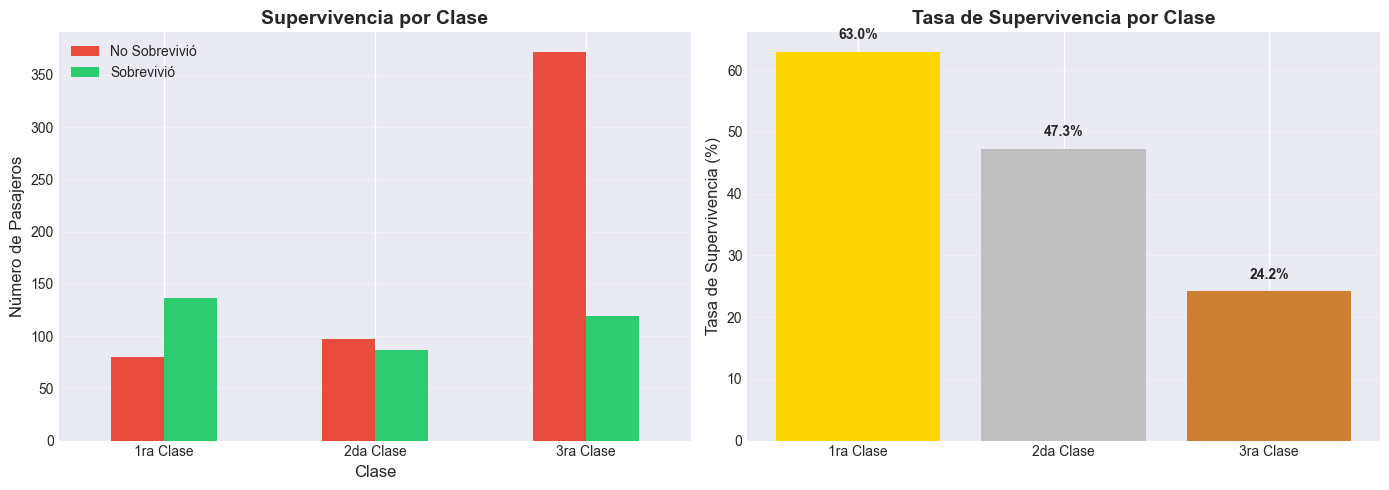


Tasa de supervivencia por clase:
Clase 1: 62.96%
Clase 2: 47.28%
Clase 3: 24.24%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras agrupadas
survival_by_class = pd.crosstab(df['pclass'], df['survived'])
survival_by_class.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Número de Pasajeros', fontsize=12)
axes[0].set_title('Supervivencia por Clase', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['1ra Clase', '2da Clase', '3ra Clase'], rotation=0)
axes[0].legend(['No Sobrevivió', 'Sobrevivió'])
axes[0].grid(axis='y', alpha=0.3)

# Tasa de supervivencia por clase
survival_rate_class = df.groupby('pclass')['survived'].mean()
axes[1].bar(['1ra Clase', '2da Clase', '3ra Clase'], survival_rate_class.values * 100, 
           color=['gold', 'silver', '#cd7f32'])
axes[1].set_ylabel('Tasa de Supervivencia (%)', fontsize=12)
axes[1].set_title('Tasa de Supervivencia por Clase', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(survival_rate_class.values * 100):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTasa de supervivencia por clase:")
for clase, rate in survival_rate_class.items():
    print(f"Clase {clase}: {rate*100:.2f}%")

### 6.3 Supervivencia por Edad

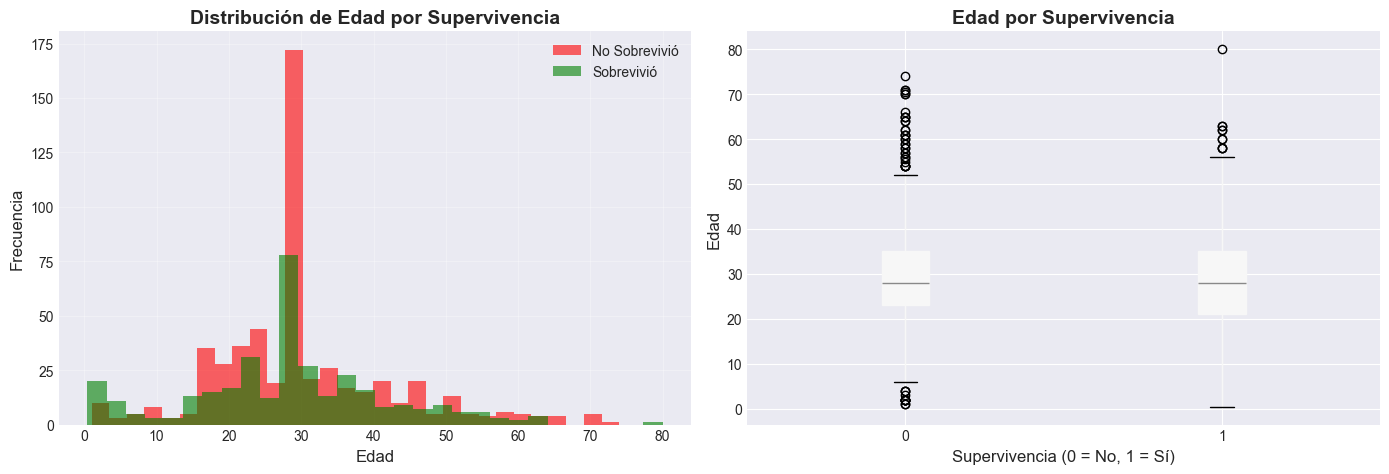


Edad promedio por supervivencia:
No sobrevivieron: 30.03 años
Sobrevivieron: 28.29 años


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de edad por supervivencia
df[df['survived'] == 0]['age'].hist(bins=30, ax=axes[0], alpha=0.6, color='red', label='No Sobrevivió')
df[df['survived'] == 1]['age'].hist(bins=30, ax=axes[0], alpha=0.6, color='green', label='Sobrevivió')
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Edad por Supervivencia', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot de edad por supervivencia
df.boxplot(column='age', by='survived', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Supervivencia (0 = No, 1 = Sí)', fontsize=12)
axes[1].set_ylabel('Edad', fontsize=12)
axes[1].set_title('Edad por Supervivencia', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nEdad promedio por supervivencia:")
print(f"No sobrevivieron: {df[df['survived']==0]['age'].mean():.2f} años")
print(f"Sobrevivieron: {df[df['survived']==1]['age'].mean():.2f} años")

### 6.4 Supervivencia por Género y Clase

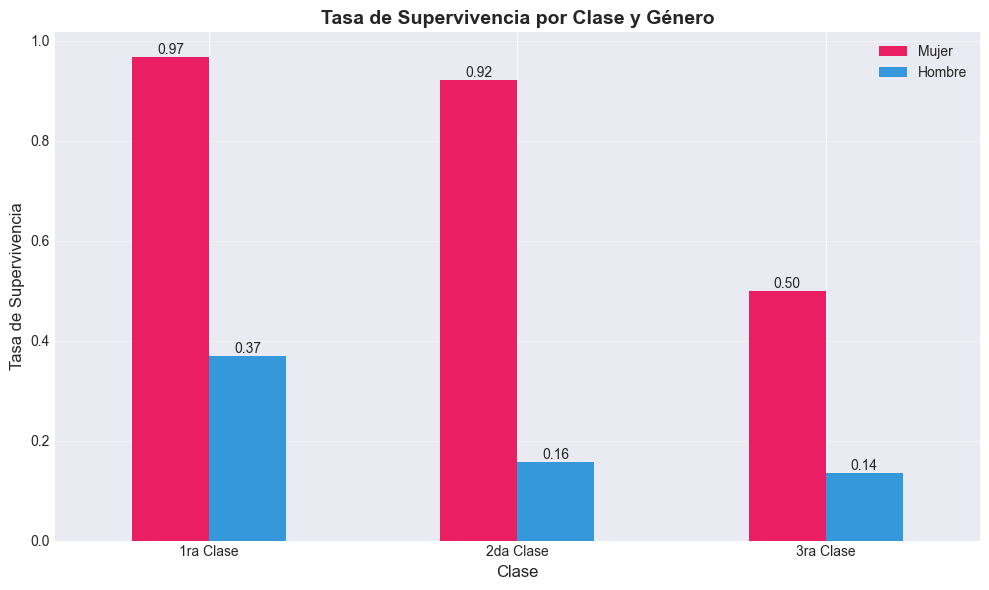


Tasa de supervivencia por clase y género:
sex       female      male
pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


In [19]:
# Crear grupos de edad
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Niño (0-12)', 'Adolescente (13-18)', 'Adulto Joven (19-35)', 
                                'Adulto (36-60)', 'Mayor (60+)'])

# Análisis cruzado
survival_gender_class = df.groupby(['pclass', 'sex'])['survived'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
survival_gender_class.plot(kind='bar', ax=ax, color=['#e91e63', '#3498db'])
ax.set_xlabel('Clase', fontsize=12)
ax.set_ylabel('Tasa de Supervivencia', fontsize=12)
ax.set_title('Tasa de Supervivencia por Clase y Género', fontsize=14, fontweight='bold')
ax.set_xticklabels(['1ra Clase', '2da Clase', '3ra Clase'], rotation=0)
ax.legend(['Mujer', 'Hombre'])
ax.grid(axis='y', alpha=0.3)

# Agregar valores
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

print("\nTasa de supervivencia por clase y género:")
print(survival_gender_class)

### 6.5 Tarifa vs Supervivencia

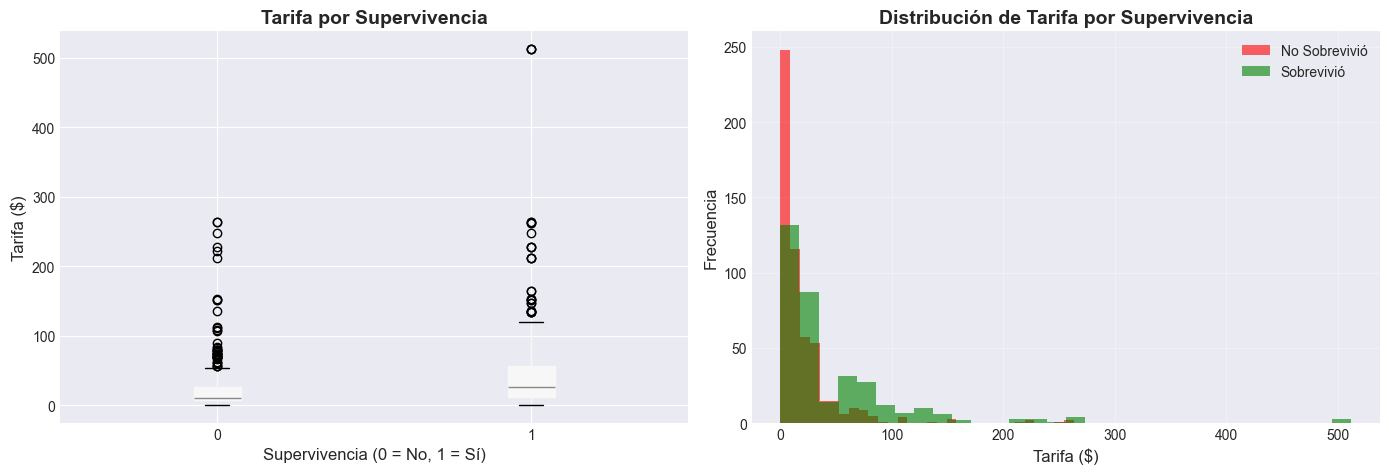


Tarifa promedio por supervivencia:
No sobrevivieron: $22.12
Sobrevivieron: $48.40


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de tarifa por supervivencia
df.boxplot(column='fare', by='survived', ax=axes[0], patch_artist=True)
axes[0].set_xlabel('Supervivencia (0 = No, 1 = Sí)', fontsize=12)
axes[0].set_ylabel('Tarifa ($)', fontsize=12)
axes[0].set_title('Tarifa por Supervivencia', fontsize=14, fontweight='bold')
plt.suptitle('')

# Distribución de tarifa por supervivencia
df[df['survived'] == 0]['fare'].hist(bins=30, ax=axes[1], alpha=0.6, color='red', label='No Sobrevivió')
df[df['survived'] == 1]['fare'].hist(bins=30, ax=axes[1], alpha=0.6, color='green', label='Sobrevivió')
axes[1].set_xlabel('Tarifa ($)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Tarifa por Supervivencia', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTarifa promedio por supervivencia:")
print(f"No sobrevivieron: ${df[df['survived']==0]['fare'].mean():.2f}")
print(f"Sobrevivieron: ${df[df['survived']==1]['fare'].mean():.2f}")

### 6.6 Familia a Bordo

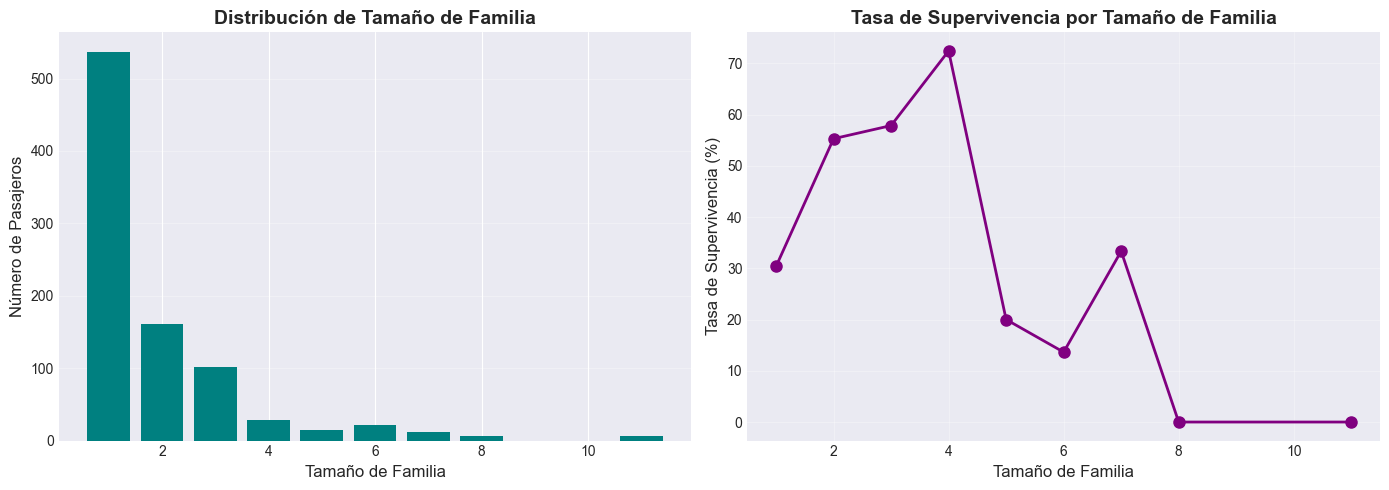


Tasa de supervivencia por tamaño de familia:
Tamaño 1: 30.35%
Tamaño 2: 55.28%
Tamaño 3: 57.84%
Tamaño 4: 72.41%
Tamaño 5: 20.00%
Tamaño 6: 13.64%
Tamaño 7: 33.33%
Tamaño 8: 0.00%
Tamaño 11: 0.00%


In [21]:
# Crear variable de tamaño de familia
df['family_size'] = df['sibsp'] + df['parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de tamaño de familia
family_counts = df['family_size'].value_counts().sort_index()
axes[0].bar(family_counts.index, family_counts.values, color='teal')
axes[0].set_xlabel('Tamaño de Familia', fontsize=12)
axes[0].set_ylabel('Número de Pasajeros', fontsize=12)
axes[0].set_title('Distribución de Tamaño de Familia', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Supervivencia por tamaño de familia
survival_by_family = df.groupby('family_size')['survived'].mean()
axes[1].plot(survival_by_family.index, survival_by_family.values * 100, 
            marker='o', linewidth=2, markersize=8, color='purple')
axes[1].set_xlabel('Tamaño de Familia', fontsize=12)
axes[1].set_ylabel('Tasa de Supervivencia (%)', fontsize=12)
axes[1].set_title('Tasa de Supervivencia por Tamaño de Familia', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTasa de supervivencia por tamaño de familia:")
for size, rate in survival_by_family.items():
    print(f"Tamaño {size}: {rate*100:.2f}%")

### 6.7 Puerto de Embarque y Supervivencia

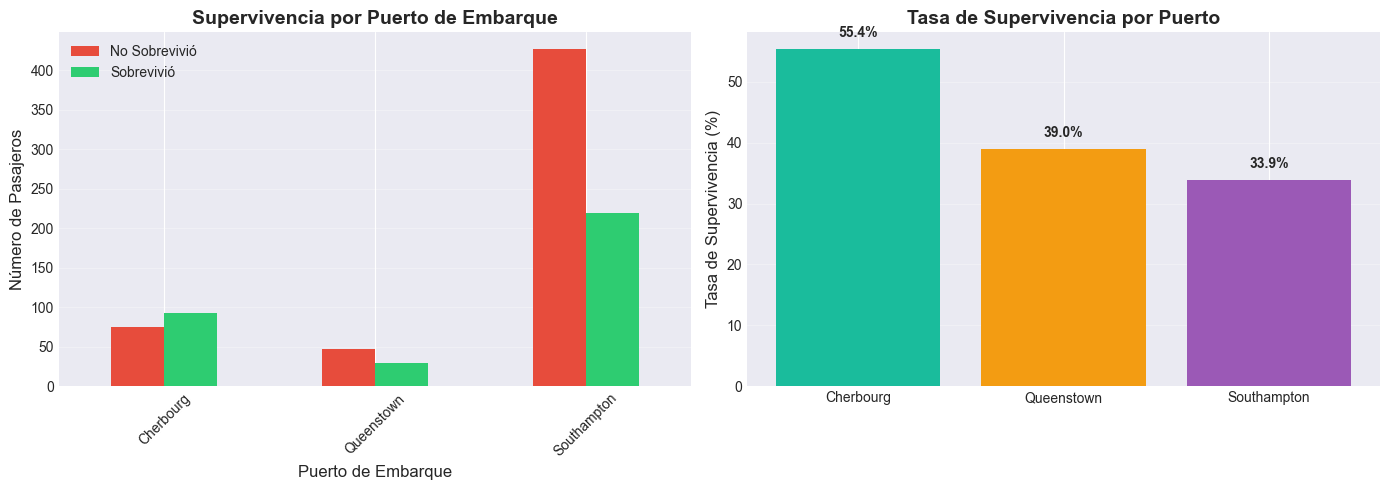


Tasa de supervivencia por puerto de embarque:
C: 55.36%
Q: 38.96%
S: 33.90%


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras agrupadas
survival_by_port = pd.crosstab(df['embarked'], df['survived'])
survival_by_port.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_xlabel('Puerto de Embarque', fontsize=12)
axes[0].set_ylabel('Número de Pasajeros', fontsize=12)
axes[0].set_title('Supervivencia por Puerto de Embarque', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'], rotation=45)
axes[0].legend(['No Sobrevivió', 'Sobrevivió'])
axes[0].grid(axis='y', alpha=0.3)

# Tasa de supervivencia por puerto
survival_rate_port = df.groupby('embarked')['survived'].mean()
axes[1].bar(['Cherbourg', 'Queenstown', 'Southampton'], survival_rate_port.values * 100,
           color=['#1abc9c', '#f39c12', '#9b59b6'])
axes[1].set_ylabel('Tasa de Supervivencia (%)', fontsize=12)
axes[1].set_title('Tasa de Supervivencia por Puerto', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(survival_rate_port.values * 100):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTasa de supervivencia por puerto de embarque:")
for port, rate in survival_rate_port.items():
    print(f"{port}: {rate*100:.2f}%")

## 7. Análisis Multivariado

### 7.1 Matriz de Correlación

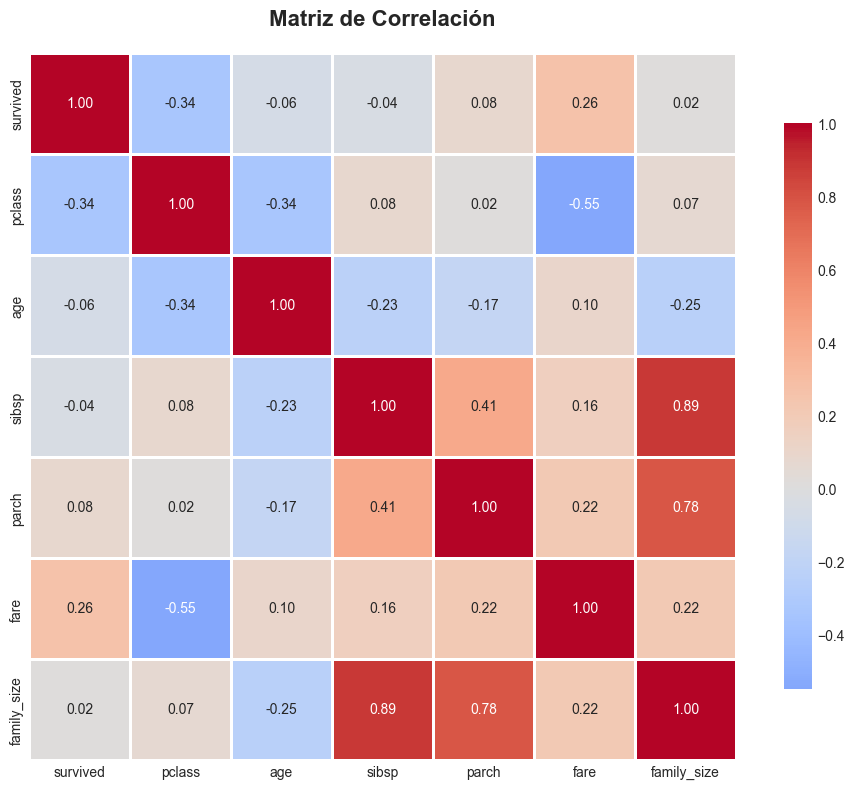


Correlaciones más fuertes con la supervivencia:
fare           0.257307
parch          0.081629
family_size    0.016639
sibsp         -0.035322
age           -0.064910
pclass        -0.338481
Name: survived, dtype: float64


In [23]:
# Seleccionar variables numéricas relevantes
numeric_features = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size']
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
           fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelaciones más fuertes con la supervivencia:")
survival_corr = correlation_matrix['survived'].sort_values(ascending=False)
print(survival_corr[survival_corr.index != 'survived'])

### 7.2 Pairplot de Variables Clave

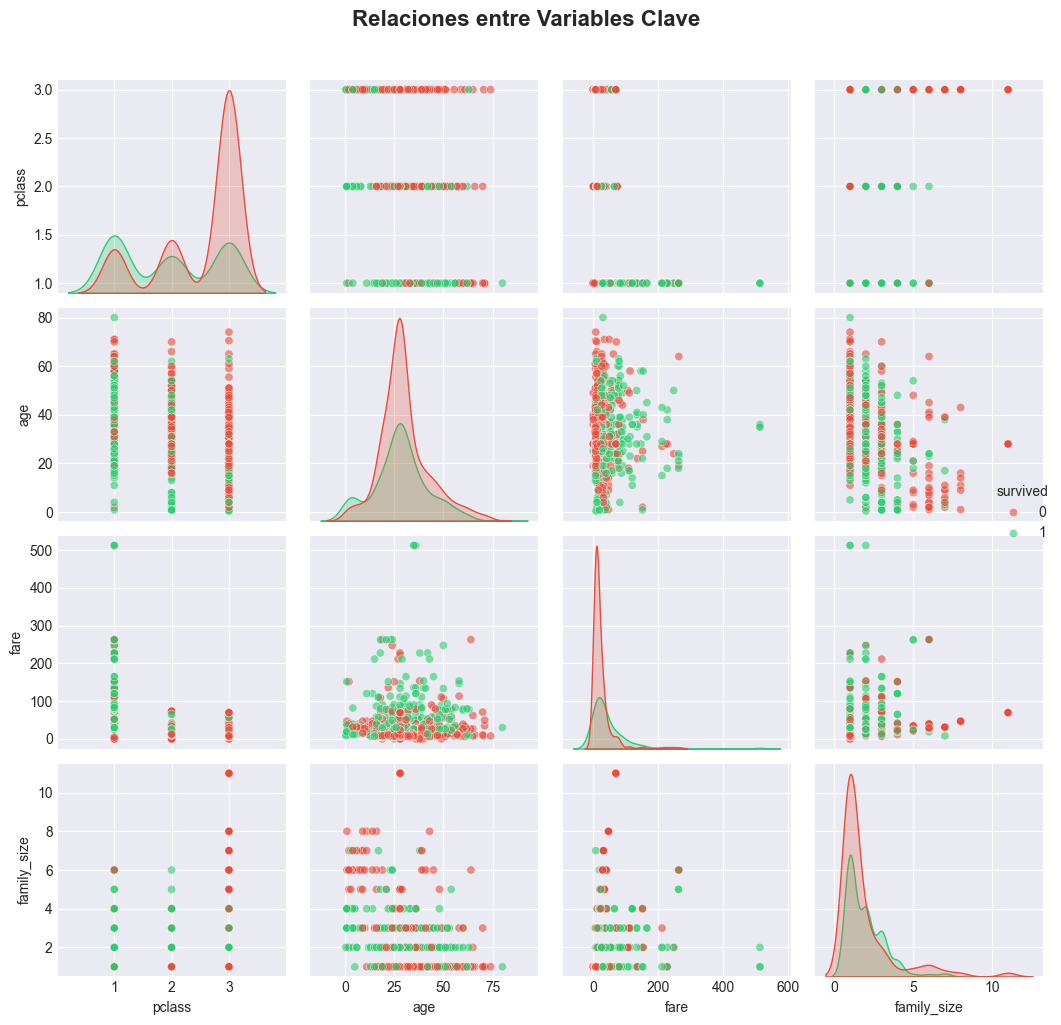

In [24]:
# Pairplot de variables clave
key_vars = ['survived', 'pclass', 'age', 'fare', 'family_size']
sns.pairplot(df[key_vars], hue='survived', palette={0: '#e74c3c', 1: '#2ecc71'}, 
            diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Relaciones entre Variables Clave', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Análisis por Grupo de Edad, Género y Clase

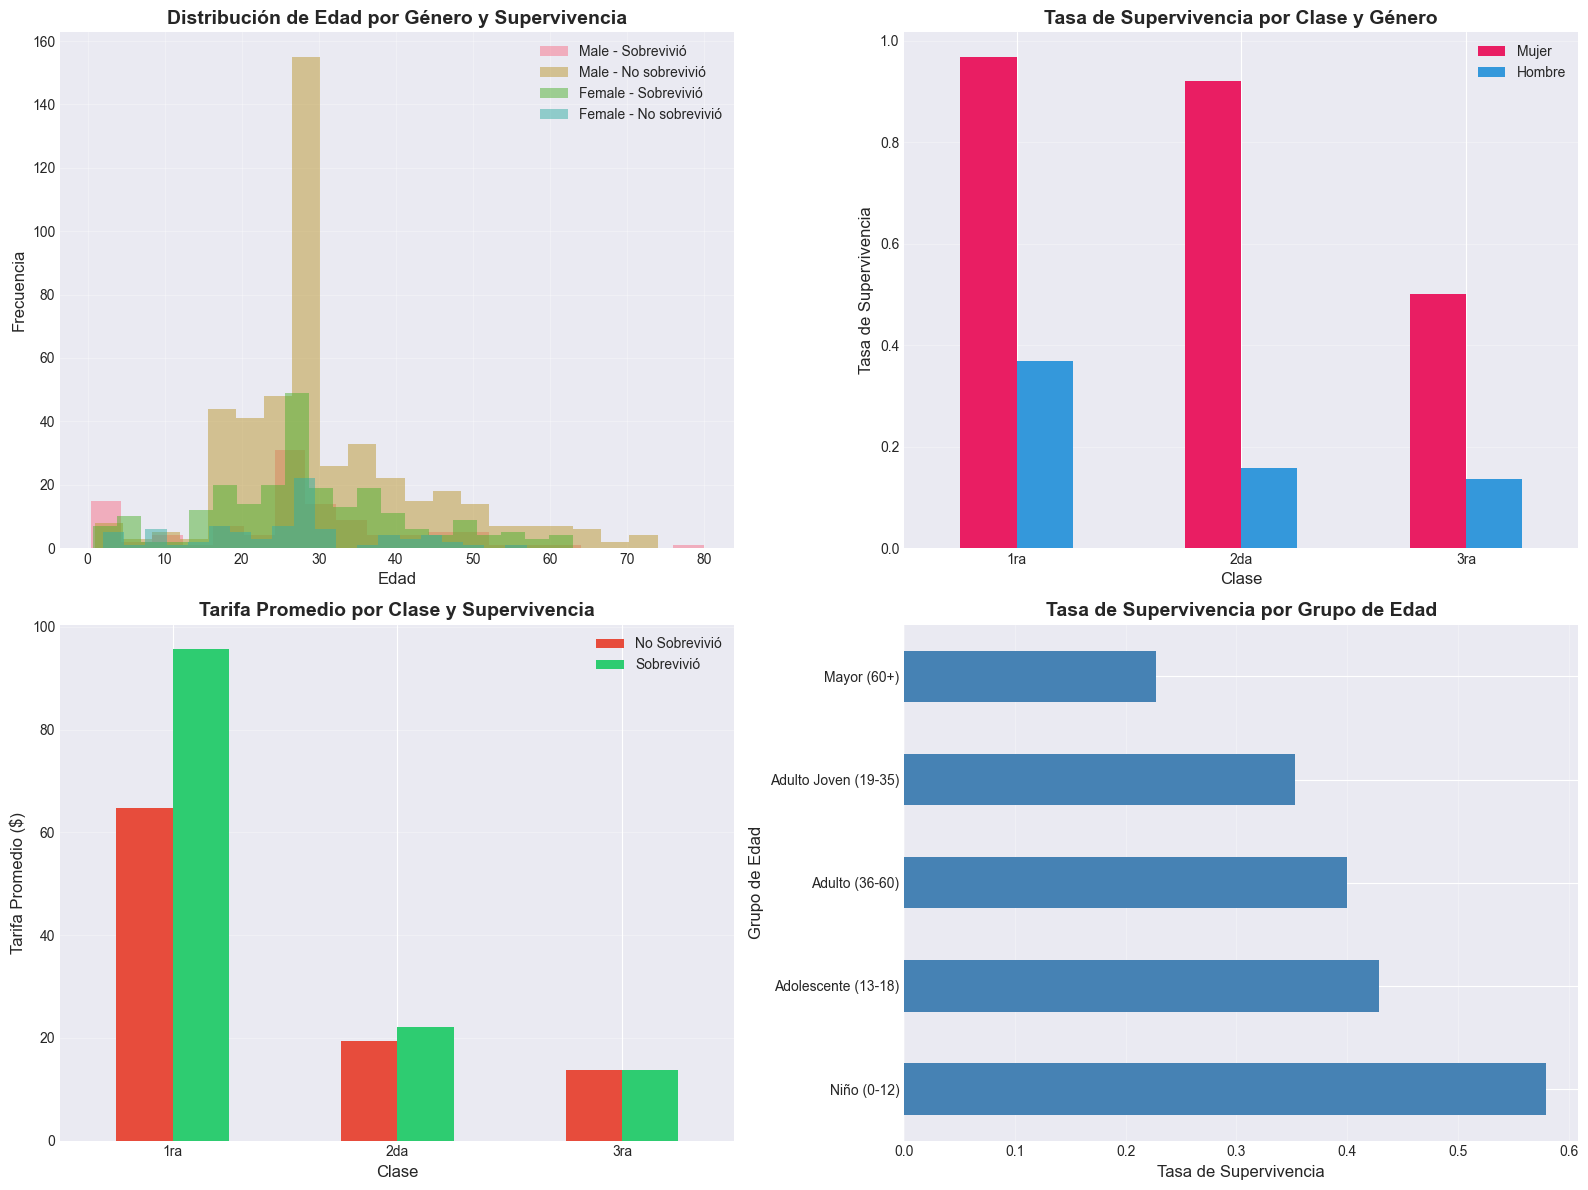

In [25]:
# Crear un análisis completo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Supervivencia por edad y género
for gender in ['male', 'female']:
    gender_data = df[df['sex'] == gender]
    survived = gender_data[gender_data['survived'] == 1]['age']
    died = gender_data[gender_data['survived'] == 0]['age']
    
    axes[0, 0].hist(survived, bins=20, alpha=0.5, label=f'{gender.capitalize()} - Sobrevivió')
    axes[0, 0].hist(died, bins=20, alpha=0.5, label=f'{gender.capitalize()} - No sobrevivió')

axes[0, 0].set_xlabel('Edad', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia', fontsize=12)
axes[0, 0].set_title('Distribución de Edad por Género y Supervivencia', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Supervivencia por clase, género
survival_pivot = df.pivot_table(values='survived', index='pclass', columns='sex', aggfunc='mean')
survival_pivot.plot(kind='bar', ax=axes[0, 1], color=['#e91e63', '#3498db'])
axes[0, 1].set_xlabel('Clase', fontsize=12)
axes[0, 1].set_ylabel('Tasa de Supervivencia', fontsize=12)
axes[0, 1].set_title('Tasa de Supervivencia por Clase y Género', fontsize=14, fontweight='bold')
axes[0, 1].set_xticklabels(['1ra', '2da', '3ra'], rotation=0)
axes[0, 1].legend(['Mujer', 'Hombre'])
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Tarifa promedio por clase y supervivencia
fare_pivot = df.pivot_table(values='fare', index='pclass', columns='survived', aggfunc='mean')
fare_pivot.plot(kind='bar', ax=axes[1, 0], color=['#e74c3c', '#2ecc71'])
axes[1, 0].set_xlabel('Clase', fontsize=12)
axes[1, 0].set_ylabel('Tarifa Promedio ($)', fontsize=12)
axes[1, 0].set_title('Tarifa Promedio por Clase y Supervivencia', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(['1ra', '2da', '3ra'], rotation=0)
axes[1, 0].legend(['No Sobrevivió', 'Sobrevivió'])
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Supervivencia por grupo de edad
age_survival = df.groupby('age_group')['survived'].mean().sort_values(ascending=False)
age_survival.plot(kind='barh', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_xlabel('Tasa de Supervivencia', fontsize=12)
axes[1, 1].set_ylabel('Grupo de Edad', fontsize=12)
axes[1, 1].set_title('Tasa de Supervivencia por Grupo de Edad', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Insights y Hallazgos Clave

### 8.1 Resumen Estadístico de Supervivencia

In [26]:
print("=" * 70)
print("INSIGHTS PRINCIPALES DEL ANÁLISIS DEL TITANIC")
print("=" * 70)

# Insight 1: Género
print("\n1. IMPACTO DEL GÉNERO EN LA SUPERVIVENCIA:")
print("-" * 70)
survival_by_gender = df.groupby('sex')['survived'].agg(['mean', 'count'])
survival_by_gender['mean'] = survival_by_gender['mean'] * 100
print(survival_by_gender)
print(f"\n→ Las mujeres tuvieron {survival_by_gender.loc['female', 'mean'] / survival_by_gender.loc['male', 'mean']:.1f}x más probabilidad de sobrevivir que los hombres")
print("→ Esto refleja la política de 'mujeres y niños primero' en los botes salvavidas")

# Insight 2: Clase social
print("\n2. IMPACTO DE LA CLASE SOCIAL:")
print("-" * 70)
survival_by_class = df.groupby('pclass')['survived'].agg(['mean', 'count'])
survival_by_class['mean'] = survival_by_class['mean'] * 100
print(survival_by_class)
print(f"\n→ Los pasajeros de 1ra clase tuvieron {survival_by_class.loc[1, 'mean'] / survival_by_class.loc[3, 'mean']:.1f}x más probabilidad de sobrevivir que los de 3ra clase")
print("→ La ubicación de los camarotes y el acceso a los botes salvavidas fue determinante")

# Insight 3: Edad
print("\n3. IMPACTO DE LA EDAD:")
print("-" * 70)
children = df[df['age'] < 18]
adults = df[df['age'] >= 18]
print(f"Tasa de supervivencia de niños (<18 años): {children['survived'].mean()*100:.2f}%")
print(f"Tasa de supervivencia de adultos (≥18 años): {adults['survived'].mean()*100:.2f}%")
print(f"\n→ Los niños tuvieron {children['survived'].mean() / adults['survived'].mean():.2f}x más probabilidad de sobrevivir")
print("→ Política de 'mujeres y niños primero' también benefició a los menores")

# Insight 4: Familia
print("\n4. IMPACTO DEL TAMAÑO DE FAMILIA:")
print("-" * 70)
alone = df[df['alone'] == True]
with_family = df[df['alone'] == False]
print(f"Tasa de supervivencia viajando solo: {alone['survived'].mean()*100:.2f}%")
print(f"Tasa de supervivencia con familia: {with_family['survived'].mean()*100:.2f}%")

# Tamaño óptimo de familia
optimal_size = df.groupby('family_size')['survived'].mean().idxmax()
optimal_rate = df.groupby('family_size')['survived'].mean().max()
print(f"\n→ Tamaño de familia óptimo: {optimal_size} personas (tasa: {optimal_rate*100:.2f}%)")
print("→ Familias muy grandes (7+) tuvieron 0% de supervivencia")

# Insight 5: Puerto de embarque
print("\n5. IMPACTO DEL PUERTO DE EMBARQUE:")
print("-" * 70)
survival_by_port = df.groupby('embark_town')['survived'].agg(['mean', 'count'])
survival_by_port['mean'] = survival_by_port['mean'] * 100
print(survival_by_port.sort_values('mean', ascending=False))
print("\n→ Cherbourg tuvo la mayor tasa (posiblemente más pasajeros de 1ra clase)")

# Insight 6: Combinación de factores
print("\n6. COMBINACIÓN DE FACTORES - GRUPOS CON MAYOR/MENOR SUPERVIVENCIA:")
print("-" * 70)
print("\nGrupo con MAYOR supervivencia:")
best = df[(df['sex'] == 'female') & (df['pclass'] == 1)]
print(f"→ Mujeres de 1ra clase: {best['survived'].mean()*100:.2f}% ({best['survived'].sum()}/{len(best)})")

print("\nGrupo con MENOR supervivencia:")
worst = df[(df['sex'] == 'male') & (df['pclass'] == 3)]
print(f"→ Hombres de 3ra clase: {worst['survived'].mean()*100:.2f}% ({worst['survived'].sum()}/{len(worst)})")

print("\n" + "=" * 70)

INSIGHTS PRINCIPALES DEL ANÁLISIS DEL TITANIC

1. IMPACTO DEL GÉNERO EN LA SUPERVIVENCIA:
----------------------------------------------------------------------
             mean  count
sex                     
female  74.203822    314
male    18.890815    577

→ Las mujeres tuvieron 3.9x más probabilidad de sobrevivir que los hombres
→ Esto refleja la política de 'mujeres y niños primero' en los botes salvavidas

2. IMPACTO DE LA CLASE SOCIAL:
----------------------------------------------------------------------
             mean  count
pclass                  
1       62.962963    216
2       47.282609    184
3       24.236253    491

→ Los pasajeros de 1ra clase tuvieron 2.6x más probabilidad de sobrevivir que los de 3ra clase
→ La ubicación de los camarotes y el acceso a los botes salvavidas fue determinante

3. IMPACTO DE LA EDAD:
----------------------------------------------------------------------
Tasa de supervivencia de niños (<18 años): 53.98%
Tasa de supervivencia de adult

### 8.2 Visualización Final: Dashboard de Supervivencia

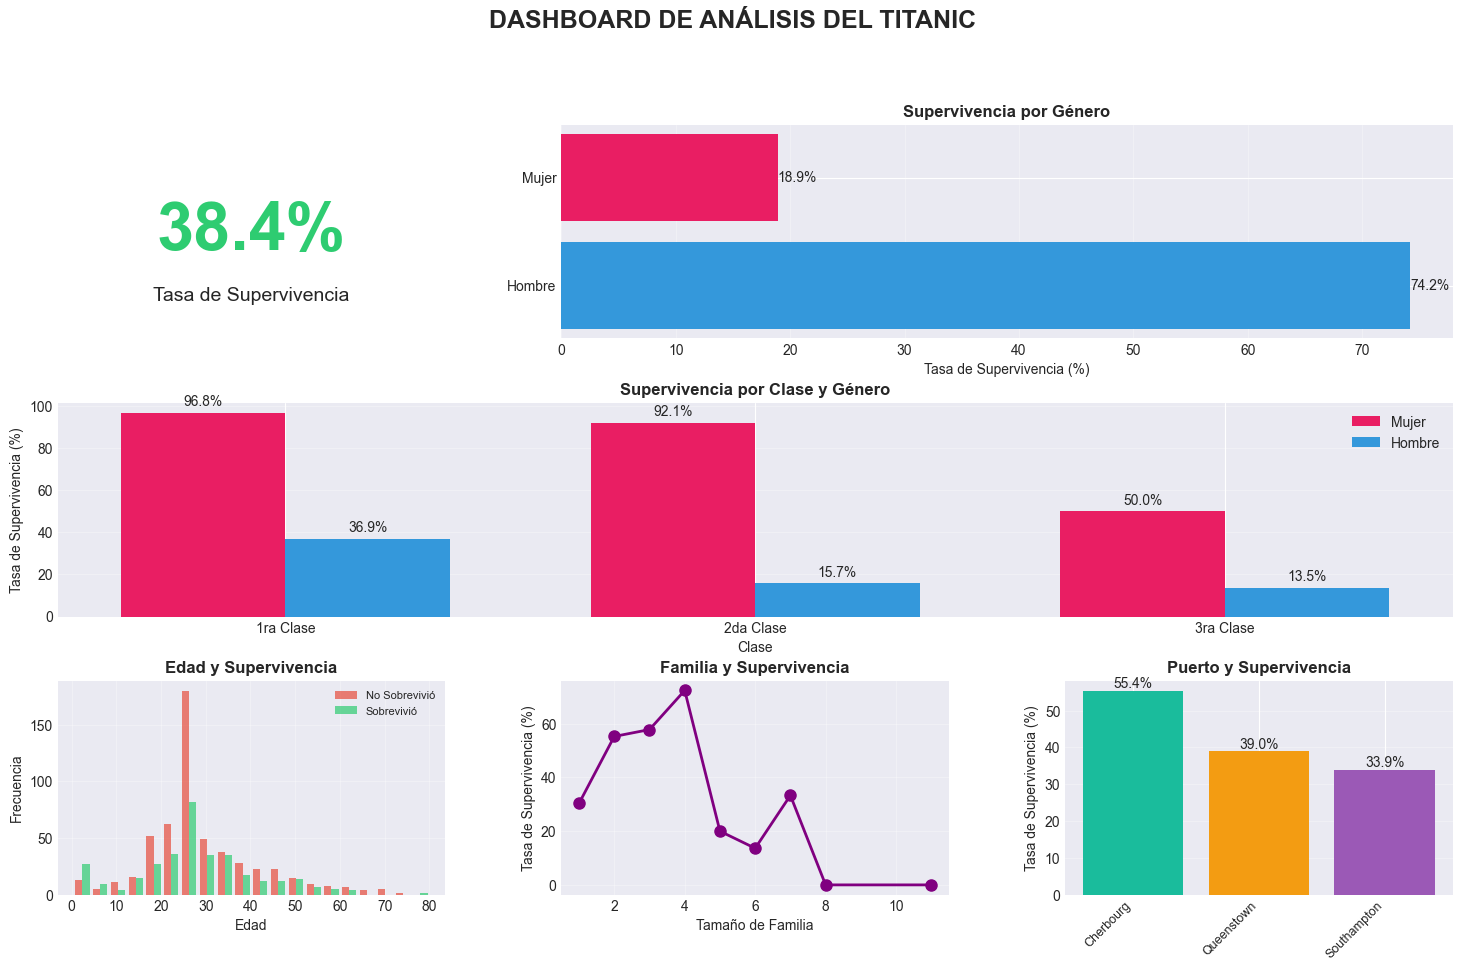

In [27]:
# Crear un dashboard final
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Tasa general de supervivencia
ax1 = fig.add_subplot(gs[0, 0])
survival_rate = df['survived'].mean() * 100
ax1.text(0.5, 0.5, f'{survival_rate:.1f}%', ha='center', va='center', 
        fontsize=48, fontweight='bold', color='#2ecc71')
ax1.text(0.5, 0.2, 'Tasa de Supervivencia', ha='center', va='center', fontsize=14)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# 2. Supervivencia por género
ax2 = fig.add_subplot(gs[0, 1:])
gender_survival = df.groupby('sex')['survived'].mean() * 100
bars = ax2.barh(['Hombre', 'Mujer'], gender_survival.values, color=['#3498db', '#e91e63'])
ax2.set_xlabel('Tasa de Supervivencia (%)', fontsize=10)
ax2.set_title('Supervivencia por Género', fontsize=12, fontweight='bold')
ax2.bar_label(bars, fmt='%.1f%%')
ax2.grid(axis='x', alpha=0.3)

# 3. Supervivencia por clase
ax3 = fig.add_subplot(gs[1, :])
class_gender = df.pivot_table(values='survived', index='pclass', columns='sex', aggfunc='mean') * 100
x = np.arange(len(class_gender.index))
width = 0.35
bars1 = ax3.bar(x - width/2, class_gender['female'], width, label='Mujer', color='#e91e63')
bars2 = ax3.bar(x + width/2, class_gender['male'], width, label='Hombre', color='#3498db')
ax3.set_xlabel('Clase', fontsize=10)
ax3.set_ylabel('Tasa de Supervivencia (%)', fontsize=10)
ax3.set_title('Supervivencia por Clase y Género', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['1ra Clase', '2da Clase', '3ra Clase'])
ax3.legend()
ax3.bar_label(bars1, fmt='%.1f%%', padding=3)
ax3.bar_label(bars2, fmt='%.1f%%', padding=3)
ax3.grid(axis='y', alpha=0.3)

# 4. Distribución de edad por supervivencia
ax4 = fig.add_subplot(gs[2, 0])
age_survived = df[df['survived'] == 1]['age']
age_died = df[df['survived'] == 0]['age']
ax4.hist([age_died, age_survived], bins=20, label=['No Sobrevivió', 'Sobrevivió'], 
        color=['#e74c3c', '#2ecc71'], alpha=0.7)
ax4.set_xlabel('Edad', fontsize=10)
ax4.set_ylabel('Frecuencia', fontsize=10)
ax4.set_title('Edad y Supervivencia', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# 5. Tamaño de familia
ax5 = fig.add_subplot(gs[2, 1])
family_survival = df.groupby('family_size')['survived'].mean() * 100
ax5.plot(family_survival.index, family_survival.values, marker='o', linewidth=2, 
        markersize=8, color='purple')
ax5.set_xlabel('Tamaño de Familia', fontsize=10)
ax5.set_ylabel('Tasa de Supervivencia (%)', fontsize=10)
ax5.set_title('Familia y Supervivencia', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3)

# 6. Puerto de embarque
ax6 = fig.add_subplot(gs[2, 2])
port_survival = df.groupby('embark_town')['survived'].mean() * 100
bars = ax6.bar(range(len(port_survival)), port_survival.values, 
              color=['#1abc9c', '#f39c12', '#9b59b6'])
ax6.set_xticks(range(len(port_survival)))
ax6.set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'], rotation=45, ha='right', fontsize=9)
ax6.set_ylabel('Tasa de Supervivencia (%)', fontsize=10)
ax6.set_title('Puerto y Supervivencia', fontsize=12, fontweight='bold')
ax6.bar_label(bars, fmt='%.1f%%')
ax6.grid(axis='y', alpha=0.3)

plt.suptitle('DASHBOARD DE ANÁLISIS DEL TITANIC', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 9. Conclusiones Finales

### Factores Determinantes de Supervivencia:

1. **Género (Factor más importante)**
   - Las mujeres tuvieron una tasa de supervivencia significativamente mayor (~74%) comparado con los hombres (~19%)
   - Refleja la política "mujeres y niños primero" durante la evacuación

2. **Clase Social**
   - Pasajeros de 1ra clase: ~63% de supervivencia
   - Pasajeros de 2da clase: ~47% de supervivencia
   - Pasajeros de 3ra clase: ~24% de supervivencia
   - La ubicación de los camarotes y acceso privilegiado a botes salvavidas fue crucial

3. **Edad**
   - Los niños tuvieron mayor probabilidad de supervivencia que los adultos
   - Los pasajeros más jóvenes en general tuvieron mejores tasas de supervivencia

4. **Tamaño de Familia**
   - Viajar con familia pequeña (2-4 personas) aumentaba las probabilidades de supervivencia
   - Viajar solo o con familia muy grande reducía significativamente las posibilidades

5. **Combinación de Factores**
   - El grupo con mayor supervivencia: Mujeres de 1ra clase (~97%)
   - El grupo con menor supervivencia: Hombres de 3ra clase (~14%)

### Insights Sociológicos:

- El desastre del Titanic expone claramente las desigualdades sociales de la época
- La clase social determinó no solo la calidad del viaje, sino las probabilidades de supervivencia
- Las normas sociales (mujeres y niños primero) se cumplieron, pero solo para ciertas clases
- La tarifa pagada correlaciona positivamente con la supervivencia, reflejando el acceso diferenciado a recursos

### Aplicaciones del Análisis:

Este tipo de análisis exploratorio es fundamental para:
- Comprender patrones en datos históricos
- Identificar factores de riesgo y protección
- Desarrollar modelos predictivos de machine learning
- Informar políticas de seguridad y evacuación en situaciones de emergencia